In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt

In [3]:
import os

for root, dirs, files in os.walk("."):
    for f in files:
        if "final_gat" in f.lower():
            print(os.path.join(root, f))

./final_gat_metrics.csv
./final_gat_predictions.csv


In [4]:
import os
print(os.getcwd())

/Users/Mourya/projects/aircraft-conflict-gnn/notebooks/processed_data


In [5]:
pred = pd.read_csv("final_gat_predictions.csv")

pred.head()

,label,probability,prediction
0,0,2.002922e-11,0
1,0,3.420755e-09,0
2,0,1.391872e-17,0
3,0,0.000000e+00,0
4,0,3.834392e-27,0


In [6]:
print("Total edges:", len(pred))

print("Actual conflicts:", pred["label"].sum())

print("Predicted conflicts:", pred["prediction"].sum())

pred.describe()

Total edges: 130899
Actual conflicts: 30
Predicted conflicts: 2094


,label,probability,prediction
count,130899.000000,1.308990e+05,130899.000000
mean,0.000229,1.682854e-02,0.015997
std,0.015137,1.128601e-01,0.125464
min,0.000000,0.000000e+00,0.000000
25%,0.000000,0.000000e+00,0.000000
50%,0.000000,3.757638e-39,0.000000
75%,0.000000,1.558670e-13,0.000000
max,1.000000,9.999917e-01,1.000000


In [7]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    pred["label"],
    pred["prediction"]
)

print(cm)

[[128785   2084]
 [    20     10]]


In [8]:
import shutil

shutil.copy(
    "final_gat_predictions.csv",
    "processed_data/final_gat_predictions.csv"
)

shutil.copy(
    "final_gat_metrics.csv",
    "processed_data/final_gat_metrics.csv"
)

print("Files copied successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'processed_data/final_gat_predictions.csv'

In [9]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current directory:
/Users/Mourya/projects/aircraft-conflict-gnn/notebooks/processed_data

Files:
['labelled_large.csv', 'train_graphs.pt', 'graphs_v1.pt', 'final_gat_metrics.csv', 'final_gat_predictions.csv', 'region_final_v1.csv', 'graphs_large.pt', '09_error_analysis.ipynb', 'pairs_df_v1.csv', 'val_graphs.pt', 'region_large.csv', 'test_graphs.pt', 'labelled_pairs_v1.csv']


In [10]:
import os

print(os.path.exists("processed_data"))

False


In [11]:
import os

project = "/Users/Mourya/projects/aircraft-conflict-gnn"

for root, dirs, files in os.walk(project):
    if "processed_data" in dirs:
        print("Found:", os.path.join(root, "processed_data"))

Found: /Users/Mourya/projects/aircraft-conflict-gnn/processed_data
Found: /Users/Mourya/projects/aircraft-conflict-gnn/notebooks/processed_data


In [12]:
import shutil

ROOT = "/Users/Mourya/projects/aircraft-conflict-gnn/processed_data"

shutil.copy(
    "final_gat_predictions.csv",
    f"{ROOT}/final_gat_predictions.csv"
)

shutil.copy(
    "final_gat_metrics.csv",
    f"{ROOT}/final_gat_metrics.csv"
)

print("✅ Files copied successfully.")

✅ Files copied successfully.


In [13]:
import os

ROOT = "/Users/Mourya/projects/aircraft-conflict-gnn/processed_data"

print(os.path.exists(f"{ROOT}/final_gat_predictions.csv"))
print(os.path.exists(f"{ROOT}/final_gat_metrics.csv"))

True
True


FileNotFoundError: [Errno 2] No such file or directory: '../results/gat_confusion_matrix.png'

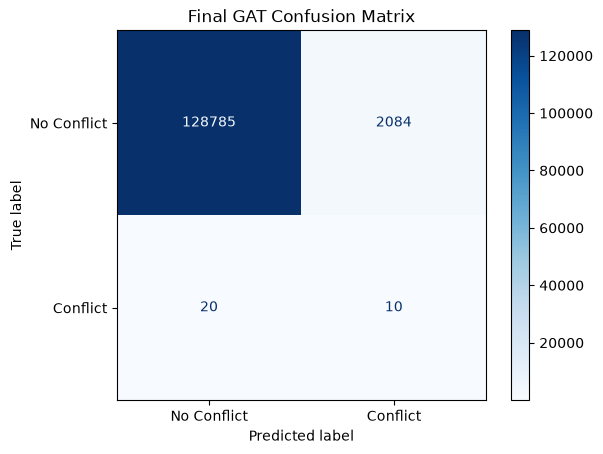

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Conflict", "Conflict"]
)

disp.plot(cmap="Blues")

plt.title("Final GAT Confusion Matrix")

plt.savefig(
    "../results/gat_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '../results/gat_roc_curve.png'

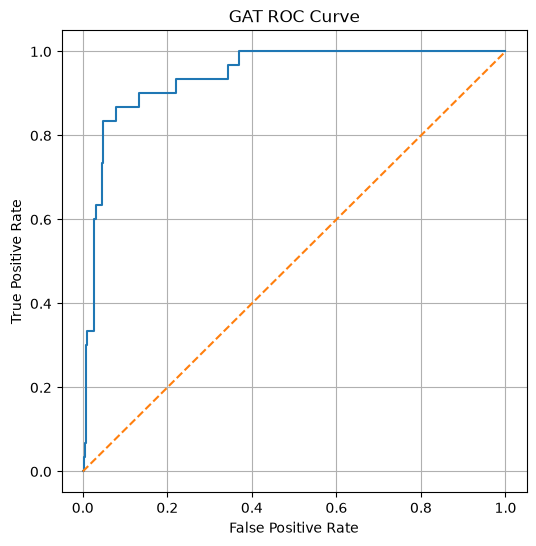

In [15]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(
    pred.label,
    pred.probability
)

plt.figure(figsize=(6,6))

plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("GAT ROC Curve")

plt.grid(True)

plt.savefig(
    "../results/gat_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
import os

print(os.getcwd())

/Users/Mourya/projects/aircraft-conflict-gnn/notebooks/processed_data


In [17]:
import os

RESULTS = "/Users/Mourya/projects/aircraft-conflict-gnn/notebooks/results"

os.makedirs(RESULTS, exist_ok=True)

print(RESULTS)

/Users/Mourya/projects/aircraft-conflict-gnn/notebooks/results


In [18]:
plt.savefig(
    os.path.join(RESULTS, "gat_roc_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

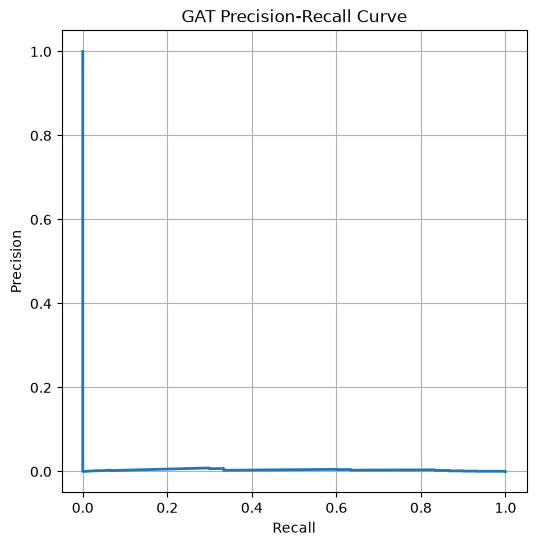

In [19]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt
import os

precision, recall, thresholds = precision_recall_curve(
    pred["label"],
    pred["probability"]
)

plt.figure(figsize=(6,6))

plt.plot(recall, precision, linewidth=2)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("GAT Precision-Recall Curve")
plt.grid(True)

plt.savefig(
    os.path.join(RESULTS, "gat_pr_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

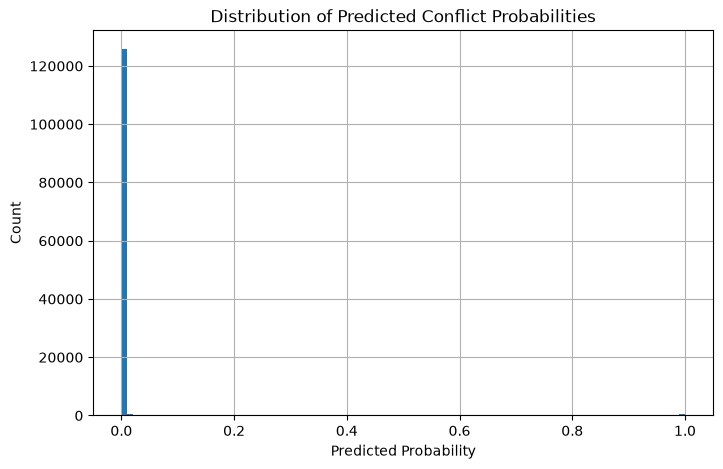

In [20]:
plt.figure(figsize=(8,5))

plt.hist(
    pred["probability"],
    bins=100
)

plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.title("Distribution of Predicted Conflict Probabilities")
plt.grid(True)

plt.savefig(
    os.path.join(RESULTS, "gat_probability_distribution.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [21]:
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

rows=[]

for t in np.arange(0.05,1.0,0.05):

    p=(pred["probability"]>=t).astype(int)

    rows.append({

        "Threshold":t,

        "Precision":precision_score(
            pred["label"],
            p,
            zero_division=0
        ),

        "Recall":recall_score(
            pred["label"],
            p,
            zero_division=0
        ),

        "F1":f1_score(
            pred["label"],
            p,
            zero_division=0
        )

    })

threshold_df=pd.DataFrame(rows)

threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.004634,0.600000,0.009198
1,0.10,0.002948,0.333333,0.005845
2,0.15,0.003240,0.333333,0.006418
3,0.20,0.003498,0.333333,0.006923
4,0.25,0.003724,0.333333,0.007366
5,0.30,0.003954,0.333333,0.007816
6,0.35,0.004195,0.333333,0.008285
7,0.40,0.004399,0.333333,0.008684
8,0.45,0.004610,0.333333,0.009095
9,0.50,0.004776,0.333333,0.009416


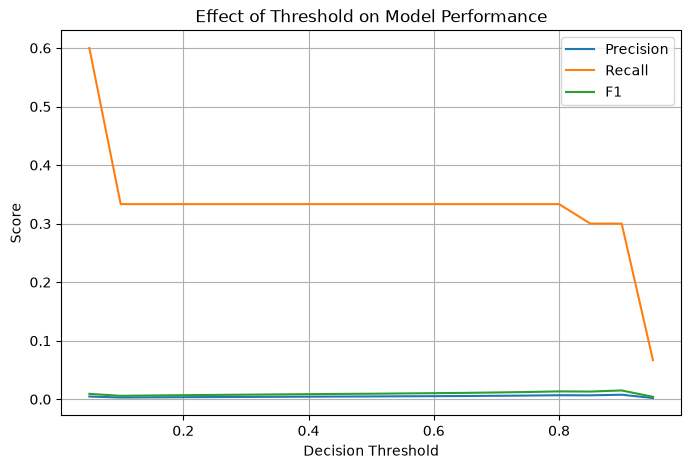

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    label="F1"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Effect of Threshold on Model Performance")

plt.legend()

plt.grid(True)

plt.savefig(
    os.path.join(RESULTS, "gat_threshold_curve.png"),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [23]:
false_positive = pred[
    (pred["label"]==0) &
    (pred["prediction"]==1)
]

print("False Positives:",len(false_positive))

false_positive.sort_values(
    "probability",
    ascending=False
).head(20)

False Positives: 2084


,label,probability,prediction
87781,0,0.999992,1
104458,0,0.999985,1
86700,0,0.999976,1
99070,0,0.999970,1
91036,0,0.999967,1
93234,0,0.999967,1
88862,0,0.999963,1
82187,0,0.999962,1
94315,0,0.999961,1
81059,0,0.999960,1


In [24]:
false_negative = pred[
    (pred["label"]==1) &
    (pred["prediction"]==0)
]

print("False Negatives:",len(false_negative))

false_negative.sort_values(
    "probability"
).head(20)

False Negatives: 20


,label,probability,prediction
20985,1,7.771276e-22,0
22363,1,1.866561e-19,0
25100,1,5.066556e-12,0
27909,1,8.227111e-08,0
29360,1,3.684803e-05,0
71,1,2.070910e-03,0
1450,1,2.232092e-03,0
2827,1,2.433411e-03,0
4153,1,2.764908e-03,0
5480,1,2.998089e-03,0


In [25]:
true_positive = pred[
    (pred["label"]==1) &
    (pred["prediction"]==1)
]

print("True Positives:",len(true_positive))

true_positive.sort_values(
    "probability",
    ascending=False
)

True Positives: 10


,label,probability,prediction
39029,1,0.990284,1
47193,1,0.982627,1
7541,1,0.947161,1
6163,1,0.944177,1
4819,1,0.939637,1
3493,1,0.933282,1
2132,1,0.929122,1
8851,1,0.927822,1
753,1,0.924874,1
37598,1,0.828390,1


In [26]:
false_positive.to_csv(
    os.path.join(RESULTS,"false_positive_cases.csv"),
    index=False
)

false_negative.to_csv(
    os.path.join(RESULTS,"false_negative_cases.csv"),
    index=False
)

true_positive.to_csv(
    os.path.join(RESULTS,"true_positive_cases.csv"),
    index=False
)

print("Case studies saved.")

Case studies saved.
